In [ ]:
# Mounting the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#unzipping the data folder
import shutil
import zipfile
import os
# 1. Clear out the old, messy directory completely
if os.path.exists('/content/IndianDataset'):
    shutil.rmtree('/content/IndianDataset')

# 2. Extract to the ROOT folder ('/content/'), NOT inside 'Train'
zip_path = '/content/drive/MyDrive/IndianDataset/Indian.zip'
data_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_path)

print("Dataset re-extracted cleanly!")

Dataset re-extracted cleanly!


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'drive', 'Indian-Traffic Sign-Dataset', 'sample_data']


In [ ]:
print(os.listdir('/content/Indian-Traffic Sign-Dataset'))

['Images', 'traffic_sign.csv']


In [ ]:
# Load CSV file
df = pd.read_csv('/content/Indian-Traffic Sign-Dataset/traffic_sign.csv')

# Show first 5 rows
df.head()

,ClassId,Name
0,0,Give way
1,1,No entry
2,2,One-way traffic
3,3,One-way traffic
4,4,No vehicles in both directions


In [ ]:
print(df.columns)

print("Total Classes:", len(df))

Index(['ClassId', 'Name'], dtype='object')
Total Classes: 59


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   ClassId  59 non-null     int64 
 1   Name     59 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [ ]:
# Core libraries
import os
import numpy as np
import pandas as pd
import random
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Scikit-learn for data splitting and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# TensorFlow and Keras for deep learning
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     BatchNormalization, Activation, GlobalAveragePooling2D)
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint

Image Shape: (32, 32, 3)


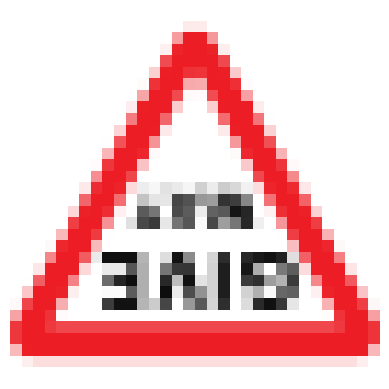

In [ ]:
# Get the ClassId for the first entry in the DataFrame
class_id = df.iloc[0]['ClassId']

# Construct the path to the directory containing images for this ClassId
# Assuming images are in /content/Indian-Traffic Sign-Dataset/Images/<ClassId>/
# and we'll pick the first image found in that directory.
images_base_dir = '/content/Indian-Traffic Sign-Dataset/Images'
class_images_dir = os.path.join(images_base_dir, str(class_id))

# Get a list of files in the class directory
image_files = os.listdir(class_images_dir)

if image_files:
    # Pick the first image file
    first_image_file = image_files[0]
    img_path = os.path.join(class_images_dir, first_image_file)

    img = cv2.imread(img_path)

    # Check if the image was loaded successfully
    if img is not None:
        print("Image Shape:", img.shape)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()
    else:
        print(f"Error: Could not load image from {img_path}")
elif os.path.exists(class_images_dir):
    print(f"Error: No images found in directory {class_images_dir}")
else:
    print(f"Error: Class directory not found: {class_images_dir}")

In [ ]:
#Load and Preprocess ALL Images

#Create Empty Lists
X = []
y = []

#Load the images
IMG_SIZE = 64
images_base_dir = '/content/Indian-Traffic Sign-Dataset/Images'
for class_folder in os.listdir(images_base_dir):
    class_path = os.path.join(images_base_dir, class_folder)
    # Skip non-folder files
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        # Read image
        img = cv2.imread(img_path)
        # Skip broken images
        if img is None:
            continue
        # Resize image
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Store image
        X.append(img)
        # Store label
        y.append(int(class_folder))

#covert list to array
X = np.array(X)
y = np.array(y)

print("Total Images Shape:", X.shape)
print("Total Labels Shape:", y.shape)

Total Images Shape: (13971, 64, 64, 3)
Total Labels Shape: (13971,)


In [ ]:
# Noramalization and Augmentation

X = X / 255.0

datagen = ImageDataGenerator(

    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

In [ ]:
#Train , validation and test Split
X_train, X_temp, y_train, y_temp = train_test_split(  X,y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training Set :", X_train.shape)
print("Validation Set :", X_val.shape)
print("Testing Set :", X_test.shape)
print('-----------------------------')
print("Training Labels :", y_train.shape)
print("Validation Labels :", y_val.shape)
print("Testing Labels :", y_test.shape)

Training Set : (9779, 64, 64, 3)
Validation Set : (2096, 64, 64, 3)
Testing Set : (2096, 64, 64, 3)
-----------------------------
Training Labels : (9779,)
Validation Labels : (2096,)
Testing Labels : (2096,)


In [ ]:
#Hot-Encoding
# Total number of classes
num_classes = np.max(y) + 1
print("Number of Classes:", num_classes)
# Encode ONLY if labels are not already one-hot encoded
if len(y_train.shape) == 1:
    y_train = to_categorical(y_train, num_classes)
    y_val = to_categorical(y_val, num_classes)
    y_test = to_categorical(y_test, num_classes)

    print("One-hot encoding applied successfully!")

else:
    print("Labels are already one-hot encoded.")

# Verify shapes
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

Number of Classes: 59
One-hot encoding applied successfully!
y_train shape: (9779, 59)
y_val shape: (2096, 59)
y_test shape: (2096, 59)


In [ ]:
#Building the model

# Ensure num_classes is a standard Python int
num_classes = int(num_classes)

model = Sequential()

# First Convolution Layer
# Correct input_shape to match IMG_SIZE (64,64,3)
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(IMG_SIZE,IMG_SIZE,3)))

model.add(BatchNormalization())

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64,(3,3),activation='relu'))

model.add(BatchNormalization())

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 59)             │         7,611 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,633,147 (6.23 MB)

 Trainable params: 1,632,955 (6.23 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
#Compile

#optimizer
optimizer=RMSprop(
    learning_rate=0.001,
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True

)

In [ ]:
#training the model
history = model.fit(X_train,
y_train,

    validation_data=(X_val, y_val),

    epochs=20,

    batch_size=32,

    callbacks=[early_stop]
)

Epoch 1/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8498 - loss: 0.4833 - val_accuracy: 0.7772 - val_loss: 0.8037
Epoch 2/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8480 - loss: 0.4815 - val_accuracy: 0.8001 - val_loss: 0.9002
Epoch 3/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8562 - loss: 0.4569 - val_accuracy: 0.7977 - val_loss: 1.1597
Epoch 4/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8613 - loss: 0.4535 - val_accuracy: 0.8087 - val_loss: 0.9985
Epoch 5/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8589 - loss: 0.4572 - val_accuracy: 0.8182 - val_loss: 1.0789
Epoch 6/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8634 - loss: 0.4450 - val_accuracy: 0.8144 - val_loss: 0.8067
Epoch 7/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8681 - loss: 0.4294 - val_accuracy: 0.8020 - val_loss: 0.7355
Epoch 8/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8696 - loss: 0.4280 - val_accuracy: 0

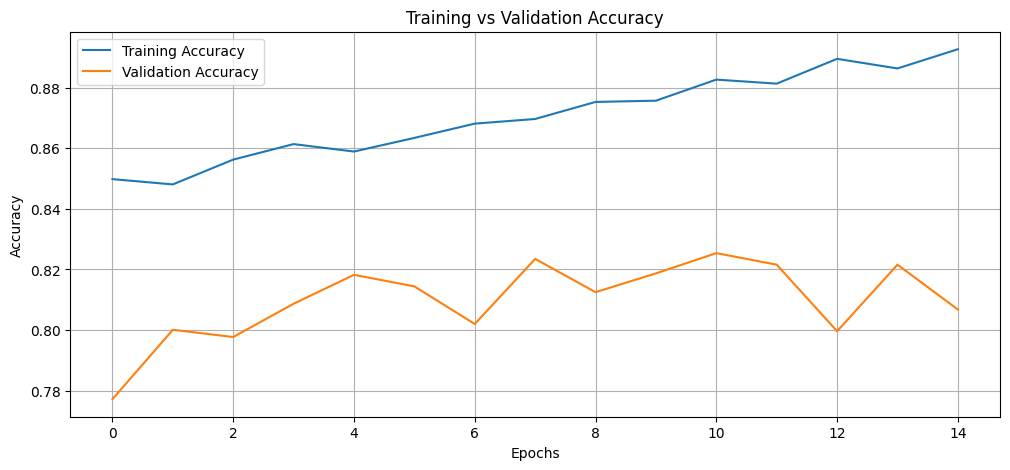

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

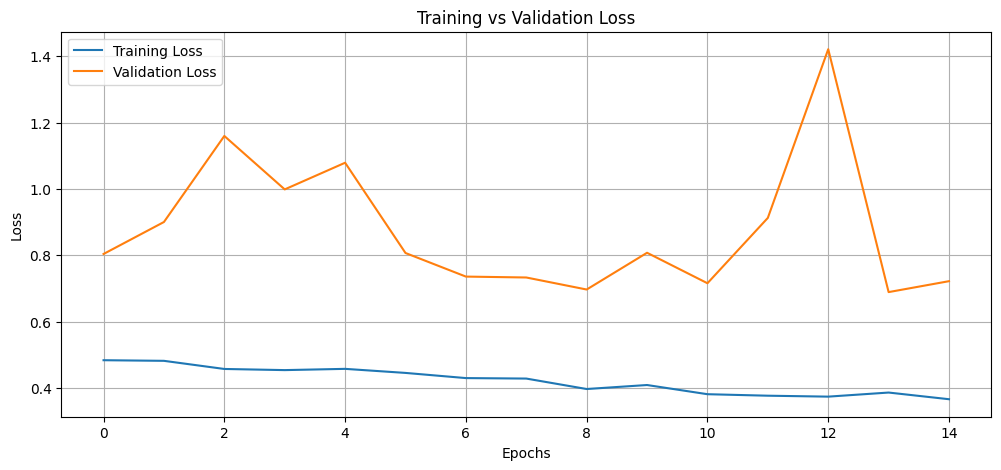

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

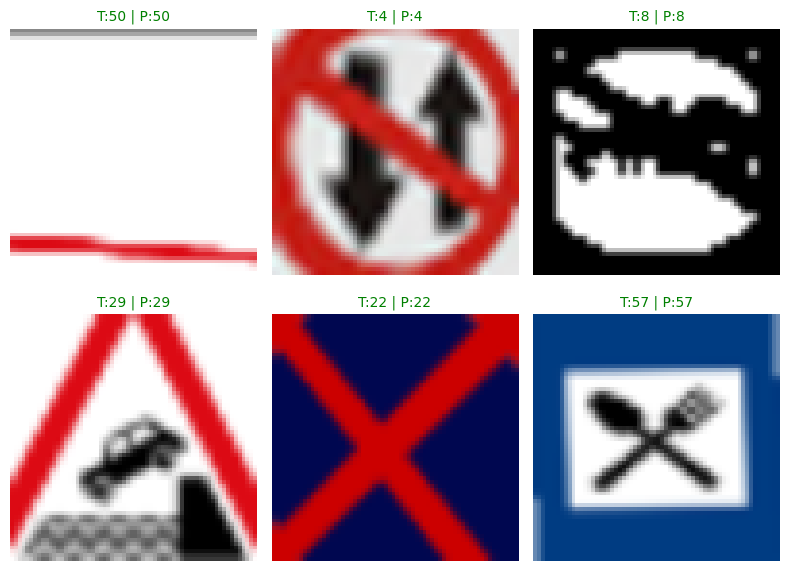

In [ ]:
#Random testing

import random
import numpy as np
import matplotlib.pyplot as plt

# Number of images
num_images = 6

# Smaller figure size
plt.figure(figsize=(8,6))

for i in range(num_images):

    # Random image
    random_index = random.randint(0, len(X_test)-1)

    sample_image = X_test[random_index]

    # True label
    true_label = np.argmax(y_test[random_index])

    # Prediction
    prediction = model.predict(
        np.expand_dims(sample_image, axis=0),
        verbose=0
    )

    predicted_label = np.argmax(prediction)

    # Plot
    plt.subplot(2,3,i+1)

    plt.imshow(sample_image)

    # Color title
    color = "green" if true_label == predicted_label else "red"

    plt.title(
        f"T:{true_label} | P:{predicted_label}",
        fontsize=10,
        color=color
    )

    plt.axis("off")

# Better spacing
plt.tight_layout()

plt.show()

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


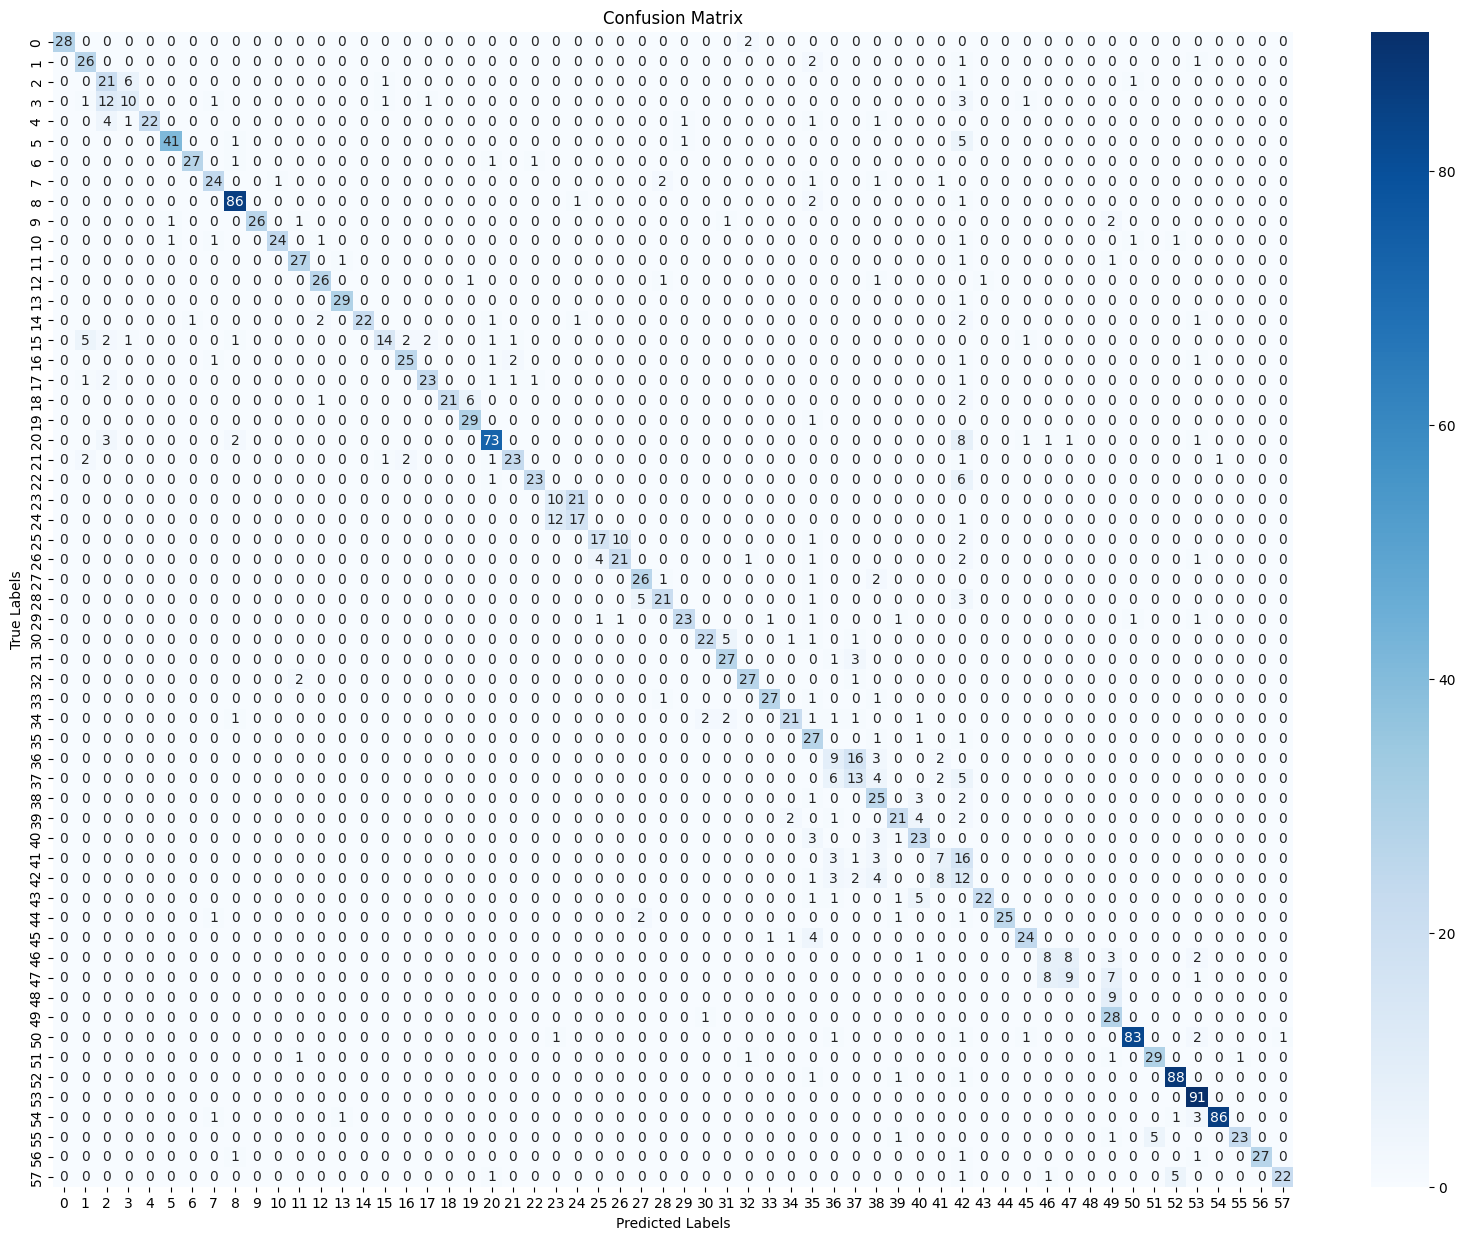


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        30
           1       0.74      0.87      0.80        30
           2       0.48      0.70      0.57        30
           3       0.56      0.33      0.42        30
           4       1.00      0.73      0.85        30
           5       0.95      0.85      0.90        48
           6       0.96      0.90      0.93        30
           7       0.83      0.80      0.81        30
           8       0.92      0.96      0.94        90
           9       1.00      0.84      0.91        31
          10       0.96      0.80      0.87        30
          11       0.87      0.90      0.89        30
          12       0.87      0.87      0.87        30
          13       0.94      0.97      0.95        30
          14       1.00      0.73      0.85        30
          15       0.82      0.47      0.60        30
          16       0.86      0.81      0.83        31
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ------------------------------
# Predict on test data
# ------------------------------

y_pred = model.predict(X_test)

# Convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot encoded test labels back to integers
y_true = np.argmax(y_test, axis=1)
# Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
# Plot Confusion Matrix

plt.figure(figsize=(20,15))

sns.heatmap(
    cm,
    cmap='Blues',
    annot=True,
    fmt='d'

)

plt.title('Confusion Matrix')

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.show()

# Classification Report
# ------------------------------

print("\nClassification Report:\n")

print(classification_report( y_true,y_pred_classes))